# 05 — Puntos e insights

Analizamos los perfiles de clientes, las ventas y las afinidades para definir reglas
de puntos y comparar su aplicación con la política fija.

**Separación temporal:** utilizamos enero–febrero de 2025 para definir segmentos, rezagos
y afinidades. Aplicamos los multiplicadores en marzo y calculamos las ventanas a partir
del primer mes de Silver. Esta separación reserva las compras de marzo para la comparación.

**Alcance:** trabajamos con datos sintéticos, saldo inicial cero y las mismas compras y canjes
en ambas políticas. Redondeamos por línea y acreditamos los puntos al terminar cada compra.
Establecemos un tope combinado de ×3. El escenario simplifica las condiciones comerciales:
no incorpora demoras de acreditación, topes diarios ni caducidad.


In [1]:
from collections import defaultdict
from decimal import Decimal, ROUND_CEILING
from hashlib import sha256
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / "doc.md").is_file()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Ejecutar desde la carpeta Caso-Estudio-2 o notebooks/.")
SILVER = PROJECT_ROOT / "data" / "silver"
GOLD = PROJECT_ROOT / "data" / "gold"
PUNTOS_POR_QUETZAL = Decimal("10")
UMBRAL_AFINIDAD = 1.2
MULT_REZAGADO = Decimal("2")
TOPE_MULTIPLICADOR = Decimal("3")
SEGMENTOS = ["Leales", "Madrugadores", "En riesgo", "Ocasionales"]

def sql_text(value):
    return "'" + str(value).replace("'", "''") + "'"

entradas = [SILVER / f"{t}.parquet" for t in
            ("clientes", "productos", "restaurantes", "compras", "lineas_compra")]
entradas += [GOLD / f"{t}.parquet" for t in
             ("perfil_clientes", "ventas_productos", "afinidad_segmento_categoria")]
faltantes = [p.name for p in entradas if not p.is_file()]
if faltantes:
    raise FileNotFoundError(f"Ejecutar 01–04; faltan: {faltantes}")
huellas_entrada = {p: sha256(p.read_bytes()).hexdigest() for p in entradas}
connection = duckdb.connect(":memory:")
connection.execute("SET threads = 1")
for path in entradas:
    connection.execute(f"CREATE VIEW {path.stem} AS SELECT * FROM read_parquet({sql_text(path)})")

perfil = connection.execute("SELECT * FROM perfil_clientes ORDER BY cliente_id").df()
if "segmento" not in perfil:
    raise ValueError("perfil_clientes no tiene segmento: ejecutar el notebook 04 después del 03.")
ventas = connection.execute("SELECT * FROM ventas_productos ORDER BY producto_id").df()
afinidad = connection.execute("SELECT * FROM afinidad_segmento_categoria ORDER BY segmento, categoria").df()
catalogo = connection.execute("SELECT * FROM productos ORDER BY id").df()
inicio_mes1, inicio_aplicacion, fin_aplicacion = connection.execute("""
    SELECT date_trunc('month', min(fecha_hora)),
           date_trunc('month', min(fecha_hora)) + INTERVAL 2 MONTH,
           date_trunc('month', min(fecha_hora)) + INTERVAL 3 MONTH
    FROM compras
""").fetchone()
assert inicio_mes1 is not None, "Silver no contiene compras"
assert perfil.cliente_id.is_unique and perfil.segmento.isin(SEGMENTOS).all()
assert set(perfil.cliente_id) == set(connection.execute("SELECT id FROM clientes").df().id)
assert set(ventas.producto_id) == set(catalogo.id) and ventas.producto_id.is_unique
assert not afinidad.duplicated(["segmento", "categoria"]).any()
assert set(zip(afinidad.segmento, afinidad.categoria)) == {
    (s, c) for s in SEGMENTOS for c in catalogo.categoria.unique()
}
assert afinidad.indice_afinidad.notna().all()
assert connection.execute("SELECT max(fecha_hora) FROM compras").fetchone()[0] < fin_aplicacion
print(f"Análisis: [{inicio_mes1.date()}, {inicio_aplicacion.date()})")
print(f"Aplicación: [{inicio_aplicacion.date()}, {fin_aplicacion.date()})")
print(f"DuckDB {duckdb.__version__}; clientes segmentados: {len(perfil):,}")

Análisis: [2025-01-01, 2025-03-01)
Aplicación: [2025-03-01, 2025-04-01)
DuckDB 1.5.5; clientes segmentados: 1,000


## 1. Reglas explicables

Definimos los incentivos a partir del rezago de productos, la afinidad y el comportamiento
de cada segmento:

| Origen | Destinatario | Multiplicador |
|---|---|---|
| Producto rezagado (`indice_ventas < 0.5`) | Segmentos con afinidad de su categoría > 1.2; si ninguno cumple, todos | ×2 |
| Ampliación de hábitos de Madrugadores | Hamburguesas y pollo, en cualquier franja | ×2 de producto |
| Reactivación de En riesgo | Todas sus líneas monetarias | ×1.5 de cliente |
| Mayor frecuencia de Ocasionales | Todas sus líneas monetarias | ×1.25 de cliente |
| Leales | Incentivos de productos aplicables | Sin regla adicional de cliente |

Cada regla de producto identifica un producto o una categoría. Un segmento nulo indica
que la regla aplica a todos los clientes. Elegimos la mayor regla de producto y como máximo
una regla de cliente; en empates seleccionamos el ID menor. Limitamos el producto de ambos
factores a ×3 y aplicamos las reglas únicamente durante marzo.


In [2]:
def generar_reglas(ventas_producto, afinidades):
    filas = []

    def agregar(tipo, multiplicador, motivo, producto_id=None, categoria=None, segmento=None):
        filas.append(dict(id=len(filas) + 1, tipo=tipo, producto_id=producto_id,
                          categoria=categoria, segmento=segmento,
                          multiplicador=multiplicador, motivo=motivo))

    for producto in ventas_producto.loc[ventas_producto.es_rezagado].sort_values("producto_id").itertuples():
        afines = afinidades.loc[(afinidades.categoria == producto.categoria)
                               & (afinidades.indice_afinidad > UMBRAL_AFINIDAD)]
        destinos = sorted(afines.segmento.unique()) or [None]
        for segmento in destinos:
            motivo = (f"Producto rezagado; afinidad > {UMBRAL_AFINIDAD} en {segmento}"
                      if segmento else "Producto rezagado; ningún segmento supera el umbral de afinidad")
            agregar("producto", MULT_REZAGADO, motivo,
                    producto_id=int(producto.producto_id), segmento=segmento)
    for categoria in ("hamburguesas", "pollo"):
        agregar("producto", Decimal("2"), "Ampliar categorías de consumo de Madrugadores",
                categoria=categoria, segmento="Madrugadores")
    agregar("cliente", Decimal("1.5"), "Reactivar clientes con recencia alta", segmento="En riesgo")
    agregar("cliente", Decimal("1.25"), "Incentivar frecuencia de clientes ocasionales", segmento="Ocasionales")
    reglas = pd.DataFrame(filas)
    reglas["producto_id"] = reglas.producto_id.astype("Int64")
    return reglas

reglas_puntos = generar_reglas(ventas, afinidad)
assert reglas_puntos.id.is_unique
assert all(Decimal("1") < m <= TOPE_MULTIPLICADOR for m in reglas_puntos.multiplicador)
reglas_producto = reglas_puntos.loc[reglas_puntos.tipo == "producto"]
assert (reglas_producto.producto_id.notna() ^ reglas_producto.categoria.notna()).all()
assert reglas_puntos.loc[reglas_puntos.tipo == "cliente", "segmento"].is_unique
display(reglas_puntos)

,id,tipo,producto_id,categoria,segmento,multiplicador,motivo
0,1,producto,4,None,Leales,2,Producto rezagado; afinidad > 1.2 en Leales
1,2,producto,8,None,Leales,2,Producto rezagado; afinidad > 1.2 en Leales
2,3,producto,24,None,Leales,2,Producto rezagado; afinidad > 1.2 en Leales
3,4,producto,28,None,En riesgo,2,Producto rezagado; afinidad > 1.2 en En riesgo
4,5,producto,<NA>,hamburguesas,Madrugadores,2,Ampliar categorías de consumo de Madrugadores
5,6,producto,<NA>,pollo,Madrugadores,2,Ampliar categorías de consumo de Madrugadores
6,7,cliente,<NA>,None,En riesgo,1.5,Reactivar clientes con recencia alta
7,8,cliente,<NA>,None,Ocasionales,1.25,Incentivar frecuencia de clientes ocasionales


## 2. Motor de puntos y movimientos

Calculamos los puntos base y dinámicos de cada línea monetaria de forma independiente:

\[
P_{base}=\lceil subtotal\times 10\rceil,\quad
M=\min(M_{producto}\times M_{cliente},3),\quad
P_{dinámico}=\lceil subtotal\times 10\times M\rceil.
\]

Multiplicamos el importe antes del redondeo final. Por ejemplo, una línea de Q12.35 con
×1.5 genera 186 puntos. Utilizamos `Decimal` para evitar errores binarios en los importes
y multiplicadores.

En enero–febrero aplicamos `M = 1` y mantenemos nulos los IDs de regla. Cada canje presenta
`puntos_base = 0`, `M = 1`, reglas nulas y un débito de `precio_en_puntos × cantidad`.


In [3]:
def elegir_reglas(producto_id, categoria, segmento, reglas):
    candidatas = reglas.loc[reglas.segmento.isna() | reglas.segmento.eq(segmento)]
    coincidencia = (candidatas.producto_id.eq(producto_id).fillna(False)
                   | (candidatas.producto_id.isna() & candidatas.categoria.eq(categoria)))
    producto = candidatas.loc[candidatas.tipo.eq("producto") & coincidencia]
    cliente = candidatas.loc[candidatas.tipo.eq("cliente")]
    assert len(cliente) <= 1, "Solo puede existir una regla de cliente aplicable"

    def mejor(tabla):
        if tabla.empty:
            return None, Decimal("1")
        fila = tabla.sort_values(["multiplicador", "id"], ascending=[False, True]).iloc[0]
        return int(fila.id), Decimal(str(fila.multiplicador))

    return mejor(producto), mejor(cliente)

def calcular_puntos(subtotal, mult_producto=Decimal("1"), mult_cliente=Decimal("1"),
                    canje=False, precio_en_puntos=0, cantidad=1):
    if canje:
        return 0, Decimal("1"), -int(precio_en_puntos) * int(cantidad)
    monto = Decimal(str(subtotal))
    assert monto >= 0
    bruto = monto * PUNTOS_POR_QUETZAL
    multiplicador = min(Decimal(str(mult_producto)) * Decimal(str(mult_cliente)), TOPE_MULTIPLICADOR)
    base = int(bruto.to_integral_value(rounding=ROUND_CEILING))
    puntos = int((bruto * multiplicador).to_integral_value(rounding=ROUND_CEILING))
    return base, multiplicador, puntos

# Se conserva el subtotal DECIMAL de Silver como texto, sin pasar por float.
detalle = connection.execute("""
    SELECT l.id AS linea_id, c.id AS compra_id, c.cliente_id, c.fecha_hora,
           l.producto_id, p.nombre AS producto, p.categoria, l.cantidad,
           l.subtotal::VARCHAR AS subtotal, l.pagado_con_puntos,
           p.precio_en_puntos, pc.segmento
    FROM lineas_compra l
    JOIN compras c ON c.id = l.compra_id
    JOIN productos p ON p.id = l.producto_id
    JOIN perfil_clientes pc ON pc.cliente_id = c.cliente_id
    ORDER BY c.fecha_hora, c.id, l.pagado_con_puntos DESC, l.id
""").df()
assert len(detalle) == connection.execute("SELECT count(*) FROM lineas_compra").fetchone()[0]
assert detalle.linea_id.is_unique
assert detalle.fecha_hora.between(inicio_aplicacion, fin_aplicacion, inclusive="left").any()

seleccion = {(int(p.id), s): elegir_reglas(int(p.id), p.categoria, s, reglas_puntos)
             for p in catalogo.itertuples() for s in SEGMENTOS}
filas_movimientos = []
for linea in detalle.itertuples():
    regla_producto, mult_producto = None, Decimal("1")
    regla_cliente, mult_cliente = None, Decimal("1")
    if inicio_aplicacion <= linea.fecha_hora < fin_aplicacion and not linea.pagado_con_puntos:
        (regla_producto, mult_producto), (regla_cliente, mult_cliente) = seleccion[(linea.producto_id, linea.segmento)]
    base, multiplicador, puntos = calcular_puntos(
        linea.subtotal, mult_producto, mult_cliente, linea.pagado_con_puntos,
        linea.precio_en_puntos, linea.cantidad,
    )
    filas_movimientos.append(dict(
        id=len(filas_movimientos) + 1, cliente_id=linea.cliente_id, linea_id=linea.linea_id,
        regla_producto_id=regla_producto, regla_cliente_id=regla_cliente,
        tipo="canje" if linea.pagado_con_puntos else "acumulacion", fecha_hora=linea.fecha_hora,
        puntos_base=base, multiplicador_aplicado=multiplicador, puntos=puntos,
    ))
movimientos_puntos = pd.DataFrame(filas_movimientos)
for columna in ("regla_producto_id", "regla_cliente_id"):
    movimientos_puntos[columna] = movimientos_puntos[columna].astype("Int64")
display(movimientos_puntos.head(8))
print(f"Movimientos: {len(movimientos_puntos):,}; uno por línea de Silver.")

,id,cliente_id,linea_id,regla_producto_id,regla_cliente_id,tipo,fecha_hora,puntos_base,multiplicador_aplicado,puntos
0,1,584,1,<NA>,<NA>,acumulacion,2025-01-01 06:00:40,245,1,245
1,2,584,2,<NA>,<NA>,acumulacion,2025-01-01 06:00:40,310,1,310
2,3,584,3,<NA>,<NA>,acumulacion,2025-01-01 06:00:40,110,1,110
3,4,394,4,<NA>,<NA>,acumulacion,2025-01-01 06:03:32,260,1,260
4,5,627,5,<NA>,<NA>,acumulacion,2025-01-01 06:04:26,180,1,180
5,6,627,6,<NA>,<NA>,acumulacion,2025-01-01 06:04:26,778,1,778
6,7,627,7,<NA>,<NA>,acumulacion,2025-01-01 06:04:26,360,1,360
7,8,422,8,<NA>,<NA>,acumulacion,2025-01-01 06:09:12,155,1,155


Movimientos: 49,525; uno por línea de Silver.


## 3. Validaciones funcionales y saldos

Verificamos el cálculo de puntos, la selección de reglas superpuestas, los desempates
y la aplicación general cuando no existe afinidad alta. Revisamos las claves, los signos,
la vigencia y el tope en todo el historial.

Para cada compra descontamos todos los canjes antes de acreditar puntos, tanto en
la política fija como en la dinámica. Así comprobamos que el cliente dispone de saldo
suficiente sin utilizar puntos de la misma compra. Seguimos el orden de fecha e ID
de compra; el ID resuelve las compras que comparten una marca de tiempo.


In [4]:
casos = [
    ("Q50 sin multiplicadores", dict(subtotal="50"), (500, Decimal("1"), 500)),
    ("Q12.35 y redondeo", dict(subtotal="12.35"), (124, Decimal("1"), 124)),
    ("Producto Q15 ×2", dict(subtotal="15", mult_producto="2"), (150, Decimal("2"), 300)),
    ("Producto ×2 y cliente ×1.5", dict(subtotal="15", mult_producto="2", mult_cliente="1.5"), (150, Decimal("3"), 450)),
    ("Tope: ×2 por ×2", dict(subtotal="15", mult_producto="2", mult_cliente="2"), (150, Decimal("3"), 450)),
    ("Redondeo final sin doble redondeo", dict(subtotal="12.35", mult_cliente="1.5"), (124, Decimal("1.5"), 186)),
    ("Canje de dos unidades", dict(subtotal="0", canje=True, precio_en_puntos=500, cantidad=2), (0, Decimal("1"), -1000)),
]
for nombre, argumentos, esperado in casos:
    assert calcular_puntos(**argumentos) == esperado, nombre

reglas_prueba = pd.DataFrame([
    dict(id=1, tipo="producto", producto_id=None, categoria="pollo", segmento=None, multiplicador=Decimal("1.5")),
    dict(id=2, tipo="producto", producto_id=99, categoria=None, segmento="Leales", multiplicador=Decimal("2")),
    dict(id=3, tipo="producto", producto_id=None, categoria="pollo", segmento="Leales", multiplicador=Decimal("2")),
    dict(id=4, tipo="cliente", producto_id=None, categoria=None, segmento="Leales", multiplicador=Decimal("1.25")),
])
reglas_prueba["producto_id"] = reglas_prueba.producto_id.astype("Int64")
assert elegir_reglas(99, "pollo", "Leales", reglas_prueba) == ((2, Decimal("2")), (4, Decimal("1.25")))
assert elegir_reglas(99, "pollo", "Ocasionales", reglas_prueba) == ((1, Decimal("1.5")), (None, Decimal("1")))
sin_afinidad = afinidad.assign(indice_afinidad=1.2)
generales = generar_reglas(ventas, sin_afinidad).query("producto_id.notna()")
assert len(generales) == int(ventas.es_rezagado.sum()) and generales.segmento.isna().all()

auditoria = detalle.merge(movimientos_puntos, on=["linea_id", "cliente_id", "fecha_hora"], validate="one_to_one")
es_canje = auditoria.tipo.eq("canje")
es_analisis = auditoria.fecha_hora.lt(inicio_aplicacion)
assert movimientos_puntos.id.is_unique and movimientos_puntos.linea_id.is_unique
assert set(movimientos_puntos.linea_id) == set(detalle.linea_id)
assert (auditoria.loc[es_canje, "puntos"] == -auditoria.loc[es_canje, "precio_en_puntos"] * auditoria.loc[es_canje, "cantidad"]).all()
assert auditoria.loc[es_canje, "puntos_base"].eq(0).all()
assert auditoria.loc[~es_canje, "puntos"].ge(auditoria.loc[~es_canje, "puntos_base"]).all()
assert auditoria.loc[~es_canje & es_analisis, "puntos"].eq(auditoria.loc[~es_canje & es_analisis, "puntos_base"]).all()
assert auditoria.loc[es_canje | es_analisis, ["regla_producto_id", "regla_cliente_id"]].isna().all().all()
assert auditoria.loc[es_canje | es_analisis, "multiplicador_aplicado"].eq(Decimal("1")).all()
assert auditoria.multiplicador_aplicado.between(Decimal("1"), TOPE_MULTIPLICADOR).all()
for columna, tipo in (("regla_producto_id", "producto"), ("regla_cliente_id", "cliente")):
    assert set(auditoria[columna].dropna()) <= set(reglas_puntos.loc[reglas_puntos.tipo.eq(tipo), "id"])

auditoria["puntos_fijos"] = np.where(es_canje, auditoria.puntos, auditoria.puntos_base)
auditoria["puntos_extra"] = np.where(es_canje, 0, auditoria.puntos - auditoria.puntos_base)
por_compra = auditoria.groupby(["fecha_hora", "compra_id", "cliente_id"], sort=True).agg(
    canje=("puntos", lambda puntos: int(puntos[puntos < 0].sum())),
    acumulacion_fija=("puntos_base", "sum"),
    acumulacion_dinamica=("puntos", lambda puntos: int(puntos[puntos >= 0].sum())),
).reset_index()
saldos_fijos, saldos_dinamicos = defaultdict(int), defaultdict(int)
for compra in por_compra.itertuples():
    cliente = compra.cliente_id
    assert saldos_fijos[cliente] + compra.canje >= 0, f"Saldo fijo insuficiente: compra {compra.compra_id}"
    assert saldos_dinamicos[cliente] + compra.canje >= 0, f"Saldo dinámico insuficiente: compra {compra.compra_id}"
    saldos_fijos[cliente] += int(compra.canje + compra.acumulacion_fija)
    saldos_dinamicos[cliente] += int(compra.canje + compra.acumulacion_dinamica)
saldos = perfil[["cliente_id", "segmento"]].copy()
saldos["saldo_fijo"] = saldos.cliente_id.map(lambda c: saldos_fijos[c])
saldos["saldo_dinamico"] = saldos.cliente_id.map(lambda c: saldos_dinamicos[c])
assert saldos.saldo_dinamico.ge(saldos.saldo_fijo).all()
assert saldos.saldo_dinamico.sum() == movimientos_puntos.puntos.sum()
assert saldos.saldo_fijo.sum() == auditoria.puntos_fijos.sum()
print(f"{len(casos)} ejemplos de cálculo, selección de reglas y fallback: correctos.")
print(f"Historial de {len(por_compra):,} compras: canjes financiados con saldo previo en ambas políticas.")
print(f"Saldo final mínimo: fijo {saldos.saldo_fijo.min():,}; dinámico {saldos.saldo_dinamico.min():,} puntos.")

7 ejemplos de cálculo, selección de reglas y fallback: correctos.
Historial de 20,000 compras: canjes financiados con saldo previo en ambas políticas.
Saldo final mínimo: fijo 150; dinámico 150 puntos.


## 4. Exportación a Gold

Guardamos las reglas y los movimientos en Parquet, con identificadores de regla anulables,
puntos enteros y multiplicadores `DECIMAL(6,2)`. Comprobamos el esquema y el contenido
de los archivos para asegurar que representan correctamente los resultados.
Cada ejecución actualiza las tablas sin acumular registros duplicados.


In [5]:
connection.register("reglas_df", reglas_puntos)
connection.register("movimientos_df", movimientos_puntos)
connection.execute("""
    CREATE TABLE salida_reglas AS
    SELECT id::INTEGER AS id, tipo::VARCHAR AS tipo, producto_id::INTEGER AS producto_id,
           categoria::VARCHAR AS categoria, segmento::VARCHAR AS segmento,
           multiplicador::DECIMAL(6,2) AS multiplicador, motivo::VARCHAR AS motivo
    FROM reglas_df ORDER BY id
""")
connection.execute("""
    CREATE TABLE salida_movimientos AS
    SELECT id::INTEGER AS id, cliente_id::INTEGER AS cliente_id, linea_id::INTEGER AS linea_id,
           regla_producto_id::INTEGER AS regla_producto_id, regla_cliente_id::INTEGER AS regla_cliente_id,
           tipo::VARCHAR AS tipo, fecha_hora::TIMESTAMP AS fecha_hora,
           puntos_base::BIGINT AS puntos_base,
           multiplicador_aplicado::DECIMAL(6,2) AS multiplicador_aplicado, puntos::BIGINT AS puntos
    FROM movimientos_df ORDER BY id
""")
GOLD.mkdir(parents=True, exist_ok=True)
for tabla, origen in (("reglas_puntos", "salida_reglas"), ("movimientos_puntos", "salida_movimientos")):
    ruta = sql_text(GOLD / f"{tabla}.parquet")
    connection.execute(f"COPY {origen} TO {ruta} (FORMAT PARQUET, COMPRESSION ZSTD)")
    connection.execute(f"CREATE VIEW releida_{tabla} AS SELECT * FROM read_parquet({ruta})")
    assert connection.execute(f"DESCRIBE {origen}").fetchall() == connection.execute(f"DESCRIBE releida_{tabla}").fetchall()
    for izquierda, derecha in ((origen, f"releida_{tabla}"), (f"releida_{tabla}", origen)):
        assert connection.execute(f"SELECT count(*) FROM (SELECT * FROM {izquierda} EXCEPT ALL SELECT * FROM {derecha})").fetchone()[0] == 0
    cantidad = connection.execute(f"SELECT count(*) FROM {origen}").fetchone()[0]
    print(f"{tabla}.parquet: {cantidad:,} filas; esquema y contenido verificados.")
assert huellas_entrada == {p: sha256(p.read_bytes()).hexdigest() for p in entradas}
connection.close()
print("Entradas intactas; exportación completa.")

reglas_puntos.parquet: 8 filas; esquema y contenido verificados.


movimientos_puntos.parquet: 49,525 filas; esquema y contenido verificados.
Entradas intactas; exportación completa.


## 5. Clientes, productos rezagados y afinidad

Describimos los segmentos mediante su tamaño y sus promedios de enero–febrero.
Comparamos las ventas de cada producto con el promedio de su categoría para identificar
los rezagados.

Medimos la afinidad mediante la presencia de cada categoría en las compras, incluidos
los canjes. Una compra puede contener varias categorías, por lo que los porcentajes
no representan categorías excluyentes ni suman necesariamente 100 %.


,clientes,recencia_dias,compras_por_mes,ticket_promedio_Q
segmento,,,,
Leales,250,1.94,12.00,102.68
Madrugadores,249,2.79,8.69,39.12
En riesgo,255,26.08,6.38,58.78
Ocasionales,246,11.25,1.36,26.41


,nombre,categoria,unidades_vendidas,indice_ventas
0,Hamburguesa especial,hamburguesas,142,0.0635
1,Sándwich de pollo especial,pollo,95,0.0521
2,Pie de manzana,postres,44,0.0343
3,Ensalada especial,ensaladas,39,0.0462


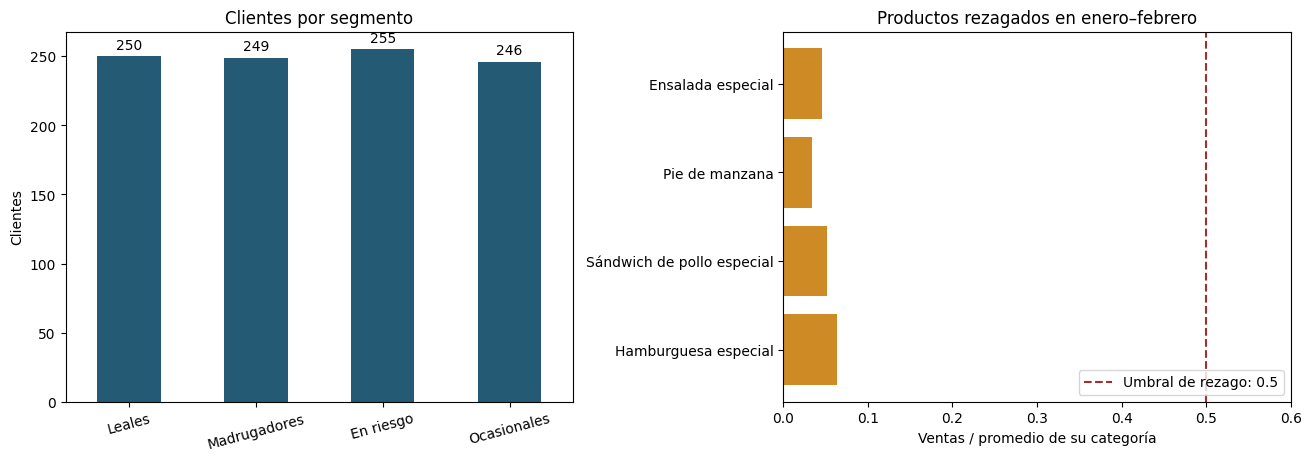

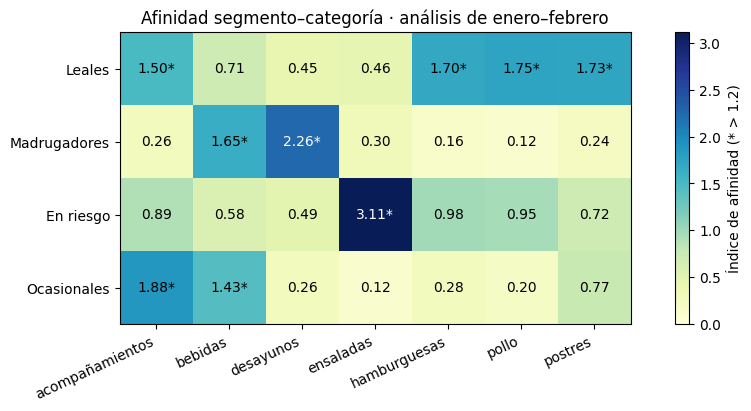

In [6]:
resumen_segmentos = perfil.groupby("segmento").agg(
    clientes=("cliente_id", "size"), recencia_dias=("recencia_dias", "mean"),
    compras_por_mes=("frecuencia_mensual", "mean"), ticket_promedio_Q=("gasto_promedio", "mean"),
).reindex(SEGMENTOS)
rezagados = ventas.loc[ventas.es_rezagado].merge(
    catalogo[["id", "nombre"]].rename(columns={"id": "producto_id"}), on="producto_id", validate="one_to_one"
)
matriz_afinidad = afinidad.pivot(index="segmento", columns="categoria", values="indice_afinidad").reindex(SEGMENTOS)
display(resumen_segmentos.round(2))
display(rezagados[["nombre", "categoria", "unidades_vendidas", "indice_ventas"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
resumen_segmentos.clientes.plot.bar(ax=axes[0], color="#245A73", rot=15)
axes[0].set(title="Clientes por segmento", xlabel="", ylabel="Clientes")
axes[0].bar_label(axes[0].containers[0], padding=3)
if not rezagados.empty:
    axes[1].barh(rezagados.nombre, rezagados.indice_ventas, color="#CE8B25")
axes[1].axvline(0.5, color="#9E3030", linestyle="--", label="Umbral de rezago: 0.5")
axes[1].set(title="Productos rezagados en enero–febrero", xlabel="Ventas / promedio de su categoría", xlim=(0, 0.6))
axes[1].legend(loc="lower right")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
mapa = ax.imshow(matriz_afinidad.to_numpy(), cmap="YlGnBu", vmin=0)
ax.set_xticks(range(len(matriz_afinidad.columns)), matriz_afinidad.columns, rotation=25, ha="right")
ax.set_yticks(range(len(SEGMENTOS)), SEGMENTOS)
ax.set_title("Afinidad segmento–categoría · análisis de enero–febrero")
for i in range(len(SEGMENTOS)):
    for j in range(len(matriz_afinidad.columns)):
        valor = matriz_afinidad.iloc[i, j]
        ax.text(j, i, f"{valor:.2f}" + ("*" if valor > UMBRAL_AFINIDAD else ""),
                ha="center", va="center", color="white" if valor > 2 else "black")
fig.colorbar(mapa, ax=ax, label="Índice de afinidad (* > 1.2)")
plt.show()

## 6. Comparación de políticas en marzo

Comparamos la emisión de puntos a partir de las acumulaciones:
`puntos_extra = puntos_dinámicos − puntos_base`. Reportamos los canjes por separado,
ya que representan el mismo débito en ambas políticas.

Calculamos el porcentaje de incremento con los puntos base de marzo como denominador.
Este indicador expresa emisión adicional de puntos, no costo monetario.


,Política,Puntos emitidos,Puntos canjeados,Movimiento neto del mes
0,Fija,4080306,1417116,2663190
1,Dinámica,4271226,1417116,2854110


Emisión adicional: 190,920 puntos (+4.68%).
Clientes con puntos extra: 605 de 907 activos en marzo.


,puntos_base,puntos_dinamicos,puntos_extra,incremento_pct,participacion_extra_pct
segmento,,,,,
Leales,3024031,3053660,29629,0.98,15.52
Madrugadores,819063,882746,63683,7.78,33.36
En riesgo,142790,216737,73947,51.79,38.73
Ocasionales,94422,118083,23661,25.06,12.39


,producto_id,producto,categoria,puntos_base,puntos_dinamicos,puntos_extra
1,2,Cuarto de libra,hamburguesas,495586,519829,24243
0,1,Big Mac,hamburguesas,427767,446635,18868
6,7,Pollo crujiente,pollo,372750,389206,16456
3,4,Hamburguesa especial,hamburguesas,13975,27950,13975
2,3,Hamburguesa con queso,hamburguesas,236880,250290,13410
4,5,McPollo,pollo,322560,335680,13120
7,8,Sándwich de pollo especial,pollo,12942,25681,12739
5,6,McNuggets 6,pollo,294975,306967,11992
24,25,Ensalada de pollo,ensaladas,79100,89165,10065
26,27,Ensalada mixta,ensaladas,60180,68172,7992


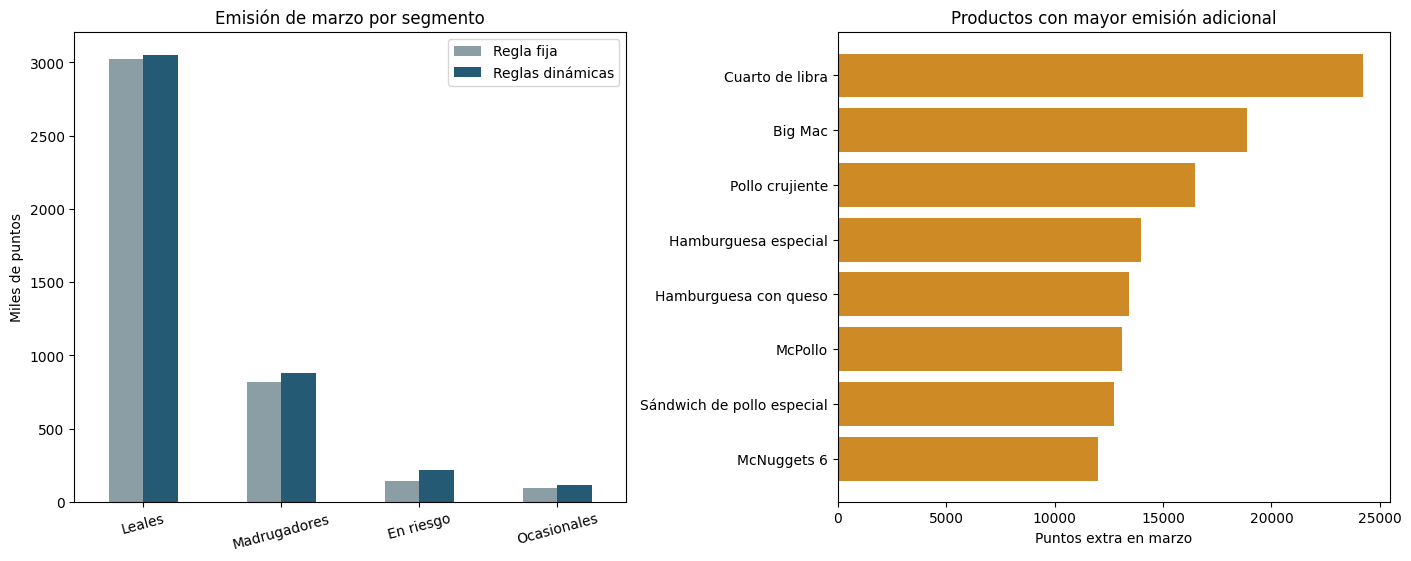

In [7]:
marzo = auditoria.loc[auditoria.fecha_hora.between(inicio_aplicacion, fin_aplicacion, inclusive="left")].copy()
acumulaciones = marzo.loc[marzo.tipo.eq("acumulacion")].copy()
base_marzo = int(acumulaciones.puntos_base.sum())
dinamicos_marzo = int(acumulaciones.puntos.sum())
extras_marzo = int(acumulaciones.puntos_extra.sum())
canjes_marzo = -int(marzo.loc[marzo.tipo.eq("canje"), "puntos"].sum())
incremento_pct = 100 * extras_marzo / base_marzo if base_marzo else 0.0
beneficiados = int(acumulaciones.loc[acumulaciones.puntos_extra.gt(0), "cliente_id"].nunique())
clientes_marzo = int(marzo.cliente_id.nunique())
assert dinamicos_marzo - base_marzo == extras_marzo
comparacion = pd.DataFrame({
    "Política": ["Fija", "Dinámica"],
    "Puntos emitidos": [base_marzo, dinamicos_marzo],
    "Puntos canjeados": [canjes_marzo, canjes_marzo],
    "Movimiento neto del mes": [base_marzo - canjes_marzo, dinamicos_marzo - canjes_marzo],
})
display(comparacion)
print(f"Emisión adicional: {extras_marzo:,} puntos (+{incremento_pct:.2f}%).")
print(f"Clientes con puntos extra: {beneficiados:,} de {clientes_marzo:,} activos en marzo.")

costo_segmento = acumulaciones.groupby("segmento").agg(
    puntos_base=("puntos_base", "sum"), puntos_dinamicos=("puntos", "sum"),
    puntos_extra=("puntos_extra", "sum"),
).reindex(SEGMENTOS, fill_value=0)
costo_segmento["incremento_pct"] = 100 * costo_segmento.puntos_extra / costo_segmento.puntos_base.replace(0, np.nan)
costo_segmento["participacion_extra_pct"] = 100 * costo_segmento.puntos_extra / extras_marzo if extras_marzo else 0.0
costo_producto = acumulaciones.groupby(["producto_id", "producto", "categoria"]).agg(
    puntos_base=("puntos_base", "sum"), puntos_dinamicos=("puntos", "sum"), puntos_extra=("puntos_extra", "sum"),
).reset_index().sort_values(["puntos_extra", "producto_id"], ascending=[False, True])
assert int(costo_segmento.puntos_extra.sum()) == extras_marzo == int(costo_producto.puntos_extra.sum())
display(costo_segmento.round(2))
display(costo_producto.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), layout="constrained")
costo_segmento[["puntos_base", "puntos_dinamicos"]].div(1000).plot.bar(
    ax=axes[0], color=["#8B9DA5", "#245A73"], rot=15
)
axes[0].set(title="Emisión de marzo por segmento", xlabel="", ylabel="Miles de puntos")
axes[0].legend(["Regla fija", "Reglas dinámicas"])
top_productos = costo_producto.head(8).sort_values("puntos_extra")
axes[1].barh(top_productos.producto, top_productos.puntos_extra, color="#CE8B25")
axes[1].set(title="Productos con mayor emisión adicional", xlabel="Puntos extra en marzo")
plt.show()

## 7. Interpretación de resultados y evaluación

Interpretamos las diferencias entre políticas sobre un conjunto fijo de compras.
Los clientes sintéticos mantienen su comportamiento, por lo que los puntos adicionales
permiten dimensionar la emisión, pero no medir un aumento de ventas.

Planteamos evaluar el efecto comercial mediante un piloto con asignación aleatoria
a tratamiento y control, presupuesto de puntos y seguimiento de frecuencia, ticket,
ventas de rezagados, canjes y margen. La conversión de puntos a costo en quetzales
requiere conocer el margen y el costo de los productos canjeados.


In [8]:
segmento_mayor = costo_segmento.puntos_extra.idxmax()
participacion = costo_segmento.loc[segmento_mayor, "participacion_extra_pct"]
display(Markdown(f"""
**Resultados de la ejecución**

- Se generaron **{len(reglas_puntos):,} reglas** y **{len(movimientos_puntos):,} movimientos**, con trazabilidad a la línea y a las reglas aplicadas.
- Se detectaron **{len(rezagados)} productos rezagados**. La afinidad dirige sus incentivos a los segmentos que ya eligen su categoría; las reglas de Madrugadores exploran categorías distintas a su hábito principal.
- En marzo, la regla fija emite **{base_marzo:,} puntos** y la dinámica **{dinamicos_marzo:,}**: **{extras_marzo:,} puntos adicionales (+{incremento_pct:.2f}%)**.
- **{beneficiados:,} de {clientes_marzo:,} clientes activos** reciben puntos extra. **{segmento_mayor}** concentra el **{participacion:.2f}%** de la emisión adicional; conviene revisar esta concentración al definir el presupuesto del piloto.
- Los canjes de marzo consumen **{canjes_marzo:,} puntos** en ambas políticas. Todos se financian con saldo previo; el saldo final mínimo es **{saldos.saldo_dinamico.min():,} puntos** bajo la política dinámica.
- La POC verifica el cálculo y la trazabilidad. **No demuestra un aumento de ventas ni rentabilidad** y no representa todas las restricciones del programa real.

Los cinco notebooks completan el flujo Bronze → Silver → Gold → ML → puntos.
La investigación de DVC y su posible adopción se documentan en [doc.md](../doc.md), sección 4.6;
DVC no es una dependencia ni una etapa ejecutada de esta POC.
"""))


**Resultados de la ejecución**

- Se generaron **8 reglas** y **49,525 movimientos**, con trazabilidad a la línea y a las reglas aplicadas.
- Se detectaron **4 productos rezagados**. La afinidad dirige sus incentivos a los segmentos que ya eligen su categoría; las reglas de Madrugadores exploran categorías distintas a su hábito principal.
- En marzo, la regla fija emite **4,080,306 puntos** y la dinámica **4,271,226**: **190,920 puntos adicionales (+4.68%)**.
- **605 de 907 clientes activos** reciben puntos extra. **En riesgo** concentra el **38.73%** de la emisión adicional; conviene revisar esta concentración al definir el presupuesto del piloto.
- Los canjes de marzo consumen **1,417,116 puntos** en ambas políticas. Todos se financian con saldo previo; el saldo final mínimo es **150 puntos** bajo la política dinámica.
- La POC verifica el cálculo y la trazabilidad. **No demuestra un aumento de ventas ni rentabilidad** y no representa todas las restricciones del programa real.

Los cinco notebooks completan el flujo Bronze → Silver → Gold → ML → puntos.
La investigación de DVC y su posible adopción se documentan en [doc.md](../doc.md), sección 4.6;
DVC no es una dependencia ni una etapa ejecutada de esta POC.
